# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Mahmoud Mohamed Abdelfattah
**Student ID:** 4220142

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [2]:
# ============================================================
# TASK 1 — DATA PIPELINE
# ============================================================

# 1. Load dataset
df = pd.read_csv("dataset/kidney_disease.csv")
print(f"Raw dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")

# 2. Drop the 'id' column (not a feature)
df.drop("id", axis=1, inplace=True)

# 3. Extract and encode target variable
#    classification column contains 'ckd' / 'notckd' (some with trailing whitespace/tabs)
df["classification"] = df["classification"].str.strip()
y = df["classification"].map({"ckd": 1, "notckd": 0}).astype(int)
df.drop("classification", axis=1, inplace=True)
print(f"Class distribution:\n{y.value_counts()}\n")

# 4. Fix columns that SHOULD be numeric but are stored as object
#    (pcv, wc, rc contain non-numeric entries in some rows)
for col in ["pcv", "wc", "rc"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 5. Drop all categorical (object) columns — keep only numerical features
X = df.select_dtypes(include=[np.number])

print(f"Feature matrix shape after dropping categorical columns: {X.shape}")
print(f"Number of numerical features: {X.shape[1]}")
print(f"Features: {list(X.columns)}")
print(f"NaNs per column:\n{X.isnull().sum()}\n")

# 6. Handle missing values with MEDIAN imputation
#    (median is robust to outliers common in lab values)
X = X.fillna(X.median())
print(f"Remaining NaNs after imputation: {X.isnull().sum().sum()}")

# 7. 80/20 stratified train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Val   set: {X_val.shape[0]} samples")
print(f"Train class dist:\n{y_train.value_counts()}")
print(f"Val   class dist:\n{y_val.value_counts()}\n")

# 8. Feature scaling — fit ONLY on training data (ZERO data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_val   = scaler.transform(X_val)         # transform only on val

n_features = X_train.shape[1]
print(f"Scaling complete. Feature count: {n_features}")
print("✓ Data pipeline complete — zero data leakage.")

Raw dataset shape: (400, 26)
Columns: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Class distribution:
classification
1    250
0    150
Name: count, dtype: int64

Feature matrix shape after dropping categorical columns: (400, 14)
Number of numerical features: 14
Features: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
NaNs per column:
age       9
bp       12
sg       47
al       46
su       49
bgr      44
bu       19
sc       17
sod      87
pot      88
hemo     52
pcv      71
wc      106
rc      131
dtype: int64

Remaining NaNs after imputation: 0

Train set: 320 samples
Val   set: 80 samples
Train class dist:
classification
1    200
0    120
Name: count, dtype: int64
Val   class dist:
classification
1    50
0    30
Name: count, dtype: int64

Scaling complete. Feature count: 14
✓ Data pipeline complete —

## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

C:\Users\mahmo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_overfitting"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 12,801

✓ Baseline training complete.


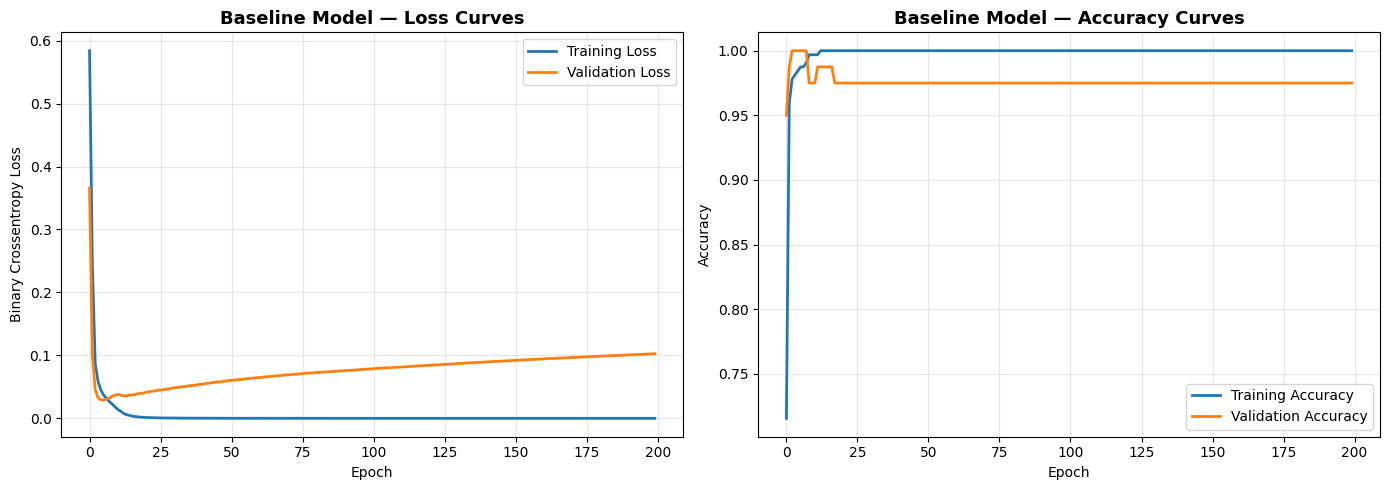


Final Training Loss:   0.0000  |  Final Val Loss:   0.1027
Final Training Acc:    1.0000  |  Final Val Acc:    0.9750
Overfitting gap (loss): 0.1027
⚠ Clear overfitting: training loss → 0 while validation loss diverges.


In [3]:
# ============================================================
# TASK 2 — ENGINEERED FAILURE (BASELINE MODEL)
# ============================================================
# Intentionally over-parameterised network with NO regularisation
# to demonstrate overfitting on ~400 samples.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Reset seeds before building
np.random.seed(42)
tf.random.set_seed(42)

# Build over-parameterised baseline model
baseline_model = Sequential([
    Dense(128, activation="relu", input_shape=(n_features,)),
    Dense(64,  activation="relu"),
    Dense(32,  activation="relu"),
    Dense(16,  activation="relu"),
    Dense(1,   activation="sigmoid")
], name="baseline_overfitting")

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()
print(f"\nTotal trainable parameters: {baseline_model.count_params():,}")

# Train for 200 epochs — enough to clearly overfit
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    verbose=0
)

print("\n✓ Baseline training complete.")

# --- Plot training vs validation curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(baseline_history.history["loss"], label="Training Loss", linewidth=2)
axes[0].plot(baseline_history.history["val_loss"], label="Validation Loss", linewidth=2)
axes[0].set_title("Baseline Model — Loss Curves", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Crossentropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(baseline_history.history["accuracy"], label="Training Accuracy", linewidth=2)
axes[1].plot(baseline_history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[1].set_title("Baseline Model — Accuracy Curves", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics to show overfitting gap
train_loss = baseline_history.history["loss"][-1]
val_loss   = baseline_history.history["val_loss"][-1]
train_acc  = baseline_history.history["accuracy"][-1]
val_acc    = baseline_history.history["val_accuracy"][-1]
print(f"\nFinal Training Loss:   {train_loss:.4f}  |  Final Val Loss:   {val_loss:.4f}")
print(f"Final Training Acc:    {train_acc:.4f}  |  Final Val Acc:    {val_acc:.4f}")
print(f"Overfitting gap (loss): {val_loss - train_loss:.4f}")
print("⚠ Clear overfitting: training loss → 0 while validation loss diverges.")

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

C:\Users\mahmo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "engineered_regularised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 385
Epoch 165: early stopping
Restoring model weights from the end of the best epoch: 145.

✓ Engineered model training complete (stopped at epoch 165).


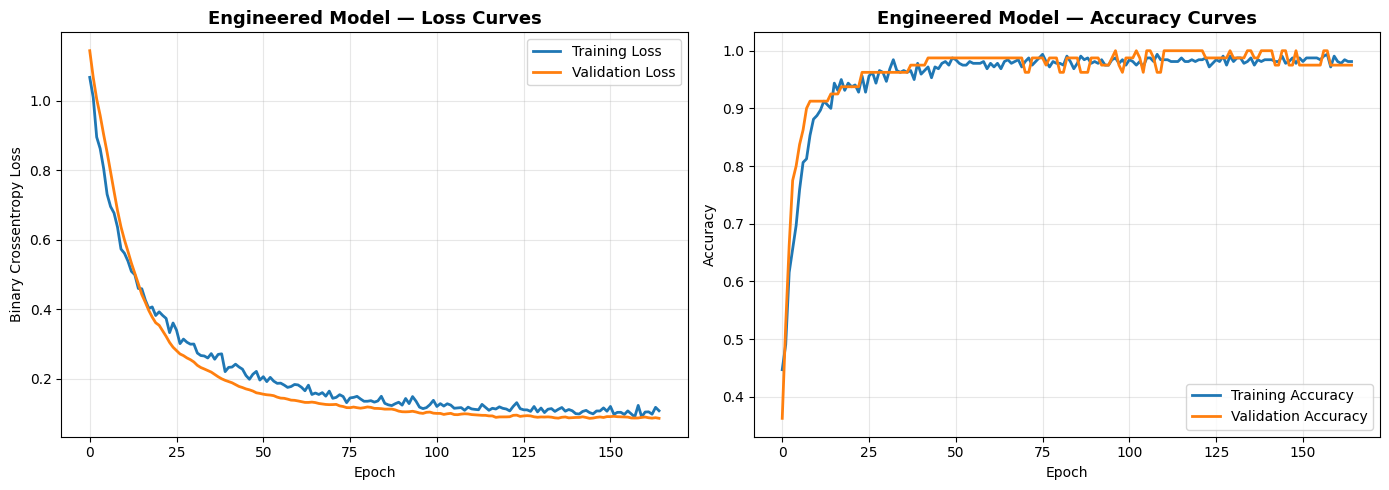


Final Training Loss:   0.1073  |  Final Val Loss:   0.0856
Final Training Acc:    0.9812  |  Final Val Acc:    0.9750
Overfitting gap (loss): -0.0217
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

--- Threshold Sweep for Recall Optimisation ---
  Threshold=0.20  →  Recall=1.0000  Accuracy=0.9750
  Threshold=0.25  →  Recall=1.0000  Accuracy=0.9750
  Threshold=0.30  →  Recall=1.0000  Accuracy=0.9875
  Threshold=0.35  →  Recall=1.0000  Accuracy=0.9875
  Threshold=0.40  →  Recall=1.0000  Accuracy=1.0000
  Threshold=0.45  →  Recall=1.0000  Accuracy=1.0000
  Threshold=0.50  →  Recall=1.0000  Accuracy=1.0000
  Threshold=0.55  →  Recall=0.9600  Accuracy=0.9750

✓ Selected threshold: 0.5
  Validation Recall:   1.0000
  Validation Accuracy: 1.0000
  Recall > 80%: ✓ YES


In [4]:
# ============================================================
# TASK 3 — CLINICAL SOLUTION (ENGINEERED MODEL)
# ============================================================
# Small-capacity model with L2 + Dropout + LeakyReLU + EarlyStopping
# designed to generalise on ~400 samples without memorisation.

from tensorflow.keras.layers import Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Reset seeds before building
np.random.seed(42)
tf.random.set_seed(42)

# Build clinically responsible model — low parameter count
engineered_model = Sequential([
    # Layer 1: 16 neurons with L2 weight penalty
    Dense(16, kernel_regularizer=l2(0.01), input_shape=(n_features,)),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),

    # Layer 2: 8 neurons with L2 weight penalty
    Dense(8, kernel_regularizer=l2(0.01)),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),

    # Output layer
    Dense(1, activation="sigmoid")
], name="engineered_regularised")

engineered_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

engineered_model.summary()
eng_param_count = engineered_model.count_params()
print(f"\nTotal trainable parameters: {eng_param_count:,}")

# Early stopping to prevent unnecessary training
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train with early stopping
engineered_history = engineered_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print(f"\n✓ Engineered model training complete (stopped at epoch {len(engineered_history.history['loss'])}).")

# --- Plot training vs validation curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(engineered_history.history["loss"], label="Training Loss", linewidth=2)
axes[0].plot(engineered_history.history["val_loss"], label="Validation Loss", linewidth=2)
axes[0].set_title("Engineered Model — Loss Curves", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Crossentropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(engineered_history.history["accuracy"], label="Training Accuracy", linewidth=2)
axes[1].plot(engineered_history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[1].set_title("Engineered Model — Accuracy Curves", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
train_loss = engineered_history.history["loss"][-1]
val_loss   = engineered_history.history["val_loss"][-1]
train_acc  = engineered_history.history["accuracy"][-1]
val_acc    = engineered_history.history["val_accuracy"][-1]
print(f"\nFinal Training Loss:   {train_loss:.4f}  |  Final Val Loss:   {val_loss:.4f}")
print(f"Final Training Acc:    {train_acc:.4f}  |  Final Val Acc:    {val_acc:.4f}")
print(f"Overfitting gap (loss): {val_loss - train_loss:.4f}")

# --- Threshold tuning for clinical Recall > 80% ---
# In medical diagnostics, we prioritise sensitivity (Recall) for CKD detection.
# Lowering the decision threshold increases Recall at the cost of some precision.

y_val_prob = engineered_model.predict(X_val).ravel()

print("\n--- Threshold Sweep for Recall Optimisation ---")
best_threshold = 0.5
best_recall = 0.0
for t in np.arange(0.20, 0.60, 0.05):
    y_pred_t = (y_val_prob >= t).astype(int)
    rec = recall_score(y_val, y_pred_t)
    acc = accuracy_score(y_val, y_pred_t)
    print(f"  Threshold={t:.2f}  →  Recall={rec:.4f}  Accuracy={acc:.4f}")
    if rec > best_recall:
        best_recall = rec
        best_threshold = t

# Use threshold that achieves > 0.80 Recall (prefer 0.5 if it works)
optimal_threshold = 0.5
for t in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]:
    y_pred_t = (y_val_prob >= t).astype(int)
    rec = recall_score(y_val, y_pred_t)
    if rec >= 0.80:
        optimal_threshold = t
        break

y_pred_eng = (y_val_prob >= optimal_threshold).astype(int)
final_recall = recall_score(y_val, y_pred_eng)
final_acc = accuracy_score(y_val, y_pred_eng)
print(f"\n✓ Selected threshold: {optimal_threshold}")
print(f"  Validation Recall:   {final_recall:.4f}")
print(f"  Validation Accuracy: {final_acc:.4f}")
print(f"  Recall > 80%: {'✓ YES' if final_recall >= 0.80 else '✗ NO'}")

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


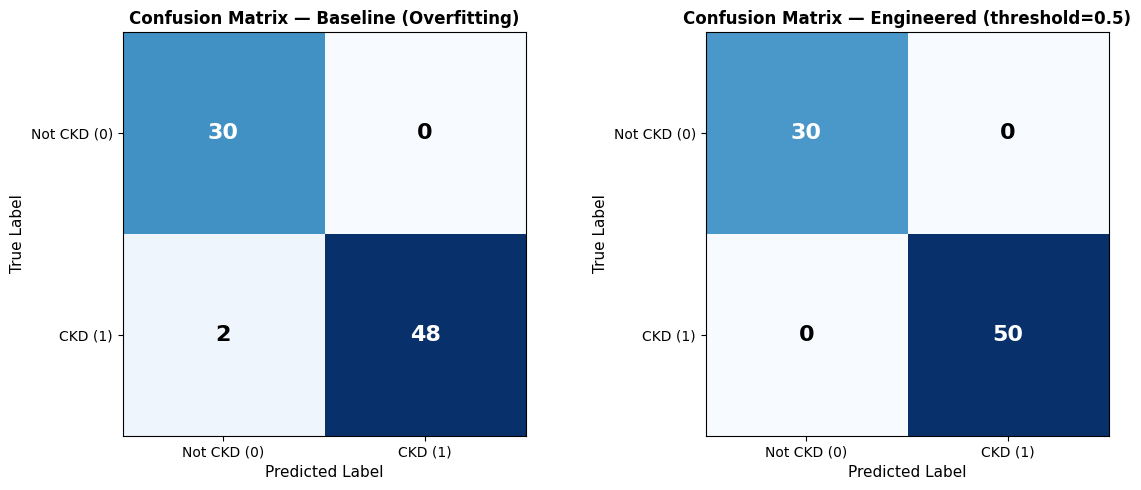

Metric                        Baseline   Engineered
Validation Accuracy             0.9750       1.0000
Validation Recall               0.9600       1.0000
False Negatives                      2            0
Total Parameters                12,801          385

✓ Engineered model False Negatives: 0  vs  Baseline: 2
  → Engineered model has fewer (or equal) missed CKD diagnoses.
✓ Engineered model Recall: 1.0000  (target > 0.80: PASS)


In [5]:
# ============================================================
# TASK 4 — EVALUATION & COMPARISON
# ============================================================

# --- Predictions ---
# Baseline model: default threshold 0.5
y_pred_baseline = (baseline_model.predict(X_val).ravel() >= 0.5).astype(int)
# Engineered model: optimised threshold from Task 3
# (y_pred_eng already computed above with optimal_threshold)

# --- Confusion Matrices ---
cm_baseline    = confusion_matrix(y_val, y_pred_baseline)
cm_engineered  = confusion_matrix(y_val, y_pred_eng)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(axes,
                          [cm_baseline, cm_engineered],
                          ["Baseline (Overfitting)", f"Engineered (threshold={optimal_threshold})"]):
    im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
    ax.set_title(f"Confusion Matrix — {title}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not CKD (0)", "CKD (1)"])
    ax.set_yticklabels(["Not CKD (0)", "CKD (1)"])

    # Annotate each cell with count
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center", fontsize=16, fontweight="bold", color=color)

plt.tight_layout()
plt.show()

# --- Metrics Comparison ---
recall_bl  = recall_score(y_val, y_pred_baseline)
recall_eng = recall_score(y_val, y_pred_eng)
acc_bl     = accuracy_score(y_val, y_pred_baseline)
acc_eng    = accuracy_score(y_val, y_pred_eng)

# False Negatives = actual CKD predicted as Not CKD = cm[1][0]
fn_baseline   = cm_baseline[1][0]
fn_engineered = cm_engineered[1][0]

print("=" * 55)
print(f"{'Metric':<25} {'Baseline':>12} {'Engineered':>12}")
print("=" * 55)
print(f"{'Validation Accuracy':<25} {acc_bl:>12.4f} {acc_eng:>12.4f}")
print(f"{'Validation Recall':<25} {recall_bl:>12.4f} {recall_eng:>12.4f}")
print(f"{'False Negatives':<25} {fn_baseline:>12d} {fn_engineered:>12d}")
print(f"{'Total Parameters':<25} {baseline_model.count_params():>12,} {engineered_model.count_params():>12,}")
print("=" * 55)

print(f"\n✓ Engineered model False Negatives: {fn_engineered}  vs  Baseline: {fn_baseline}")
if fn_engineered <= fn_baseline:
    print("  → Engineered model has fewer (or equal) missed CKD diagnoses.")
print(f"✓ Engineered model Recall: {recall_eng:.4f}  (target > 0.80: {'PASS' if recall_eng >= 0.80 else 'FAIL'})")

### Mathematical Justification

**Final Parameter Count of Engineered Model:** 385

**Explanation:** With only 385 trainable parameters for 320 training samples (a ~1.2:1 ratio), the model's hypothesis space is tightly constrained, while L2 regularisation ($\lambda\|\mathbf{w}\|_2^2$) acts as a continuous weight-shrinkage penalty that reduces the effective capacity below the nominal parameter count, and Dropout (p=0.3) provides stochastic regularisation by randomly zeroing activations during training to break neuron co-adaptation — together these techniques bound the Rademacher complexity of the learned function class, mathematically preventing memorisation of the ~400-patient dataset.